In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Asymmetry

The process:
1. Find the center of the lesion
2. Split it down horizontally/vertically in the middle
3. Overlap the lesion by flipping it over the axis
4. Compute overlap
5. Average horizontal/vertical symmetry scores

## Compute centeroid

(np.float64(-0.5), np.float64(625.5), np.float64(625.5), np.float64(-0.5))

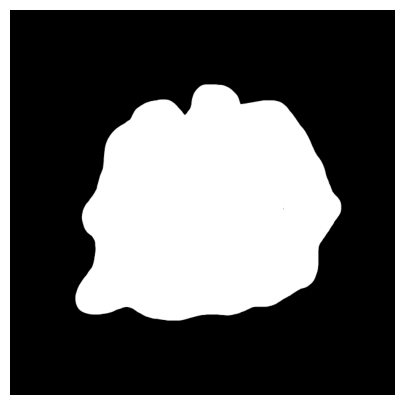

In [90]:
image = cv2.imread("../data/masks/PAT_147_219_206_mask.png") # load the image
#image = cv2.imread("circle.jpg") # testing on circle for correctness
# visualize
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis("off")

In [91]:
# convert to grayscale from RGB (single channel)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

# turn grayscale into binary image
_, mask = cv2.threshold(gray, 127, 1, cv2.THRESH_BINARY)

# compute moments on mask
M = cv2.moments(mask)
 
# calculate x,y coordinate of center
cX = int(M["m10"] / M["m00"]) # m00 = # of white pixels
cY = int(M["m01"] / M["m00"]) # m10 / m01 = sum of x / y pixels

(np.float64(-0.5), np.float64(625.5), np.float64(625.5), np.float64(-0.5))

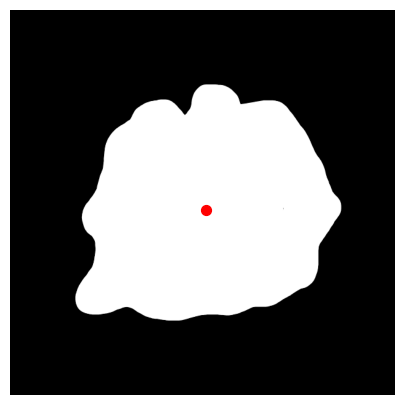

In [92]:
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.scatter(cX, cY, color="red", s=50)
plt.axis("off")

## Split image along axes

(np.float64(-0.5), np.float64(625.5), np.float64(625.5), np.float64(-0.5))

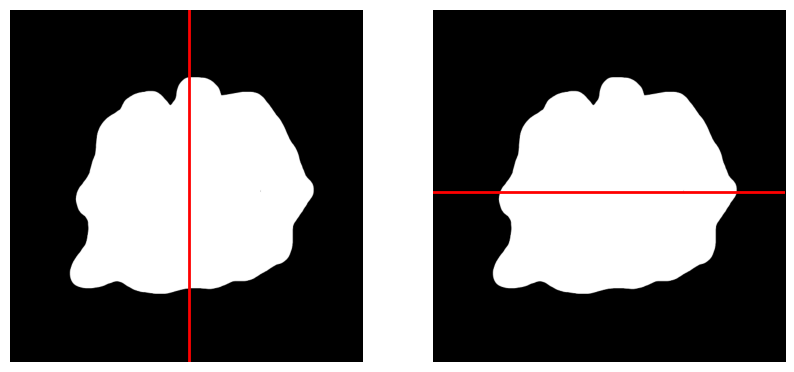

In [93]:
# visualize
fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].imshow(image)
axes[0].axvline(cX, color="red", linewidth=2)
axes[0].axis("off")

axes[1].imshow(image)
axes[1].axhline(cY, color="red", linewidth=2)
axes[1].axis("off")

### Flipping vertically

In [94]:
left = mask[:, :cX] # all rows, everything left of center
right = mask[:, cX:] # all rows, everything right of center

right_flipped = np.fliplr(right) # right flips to the left

min_w = min(left.shape[1], right_flipped.shape[1]) # min cols in left and right

left_crop  = left[:, -min_w:] # all rows, rightmost part of left
right_crop = right_flipped[:, :min_w] # all rows, leftmost part of flipped right

overlap = np.sum((left_crop == 1) & (right_crop == 1)) # pixels that are white on both sides
union = np.sum((left_crop == 1) | (right_crop == 1)) # pixels white on either side

symmetry_vertical = overlap / union
symmetry_vertical

np.float64(0.8387678459658431)

### Flipping horizontally

In [95]:
top = mask[:cY,:] # all cols, everything top of center
bottom = mask[cY:,:] # all cols, everything bottom of center

bottom_flipped = np.flipud(bottom) # bottom flips upward

min_h = min(top.shape[0], bottom_flipped.shape[0]) # min rows in top and bottom

top_crop = top[-min_h:, :] # all cols, bottommost part of top
bottom_crop = bottom_flipped[:min_h, :] # all cols, upmost part of bottom flipped

overlap = np.sum((top_crop == 1) & (bottom_crop == 1)) # pixels white on both sides
union = np.sum((top_crop == 1) | (bottom_crop == 1)) # pixels white on either side

symmetry_horizontal = overlap / union
symmetry_horizontal

np.float64(0.8415121936658607)

In [96]:
symmetry_total = (symmetry_vertical + symmetry_horizontal) / 2
symmetry_total

np.float64(0.840140019815852)